# Laplaciano y Laplaciano del Gaussiano (LoG)

Este notebook muestra la teoría, implementación y ejemplos visuales del operador Laplaciano y del Laplaciano del Gaussiano (LoG) para detección de bordes.

## Teoría (resumen)

- **Laplaciano**: es un operador isotrópico de segunda derivada (∇²) que responde a cambios rápidos de intensidad en todas las direcciones. Detecta bordes donde la segunda derivada cruza por cero o tiene picos. Es sensible al ruido porque las segundas derivadas amplifican variaciones de alta frecuencia.

- **Laplaciano del Gaussiano (LoG)**: primero aplica un suavizado Gaussiano (para reducir ruido) y luego el Laplaciano. Esto reduce respuestas espurias por ruido y facilita detectar bordes más robustos. En la práctica se suele aplicar `GaussianBlur` seguido de `Laplacian`, o usar un filtro LoG combinado (kernel precomputado).

- **Diferencias clave**: LoG = smoothing + Laplacian → menos ruido, mejor para imágenes ruidosas; Laplaciano directo es más simple y más sensible al ruido. LoG detecta cambios mediante *zero-crossings* (cambios de signo) del resultado del Laplaciano sobre la imagen suavizada.

- **Parámetros importantes**: sigma (desvío de la Gaussiana), tamaño del kernel (debe ser suficientemente grande respecto a sigma), y el tipo de normalización/escala del Laplaciano (para visualización a veces se toma el valor absoluto o se reescala).

In [ ]:
# Importar librerías y cargar una imagen de ejemplo (busca 'imagen1.png' y, si no existe, usa una imagen de skimage)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
try:
    from skimage import data
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

# Cargar imagen inline: busca 'imagen1.png' y, si no existe, usa skimage (astronaut o camera)
path = 'imagen1.png'
if os.path.exists(path):
    img = cv2.imread(path)
    if img is None:
        raise IOError(f'El archivo {path} existe pero cv2.imread() no pudo leerlo.')
elif _HAS_SKIMAGE:
    try:
        img_sk = data.astronaut()
        img = cv2.cvtColor(img_sk, cv2.COLOR_RGB2BGR)
    except Exception:
        img_sk = data.camera()
        img = cv2.cvtColor(img_sk, cv2.COLOR_GRAY2BGR)
else:
    raise FileNotFoundError('No se encontró "imagen1.png" y skimage no está disponible para usar imagen de prueba.')

plt.figure(figsize=(6,6))
plt.title('Imagen de entrada')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
# Funciones: Laplaciano directo y Laplaciano del Gaussiano (LoG)
def laplaciano_directo(gray, ksize=3, scale=1, delta=0):
    # cv2.Laplacian usa ddepth; CV_64F para preservar signo y valores negativos
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=ksize, scale=scale, delta=delta)
    return lap

def log_via_suavizado(gray, gaussian_ksize=7, sigma=1.4, lap_ksize=3):
    # Suavizamos primero con Gaussiana y luego aplicamos Laplaciano
    blur = cv2.GaussianBlur(gray, (gaussian_ksize, gaussian_ksize), sigma)
    lap = cv2.Laplacian(blur, cv2.CV_64F, ksize=lap_ksize)
    return lap, blur

# Preparar imagen en escala de grises (float64 para preservar signos)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)

lap_direct = laplaciano_directo(gray, ksize=3)
log_res, blur = log_via_suavizado(gray, gaussian_ksize=7, sigma=1.4, lap_ksize=3)

# Función auxiliar para convertir a imagen visualizable (reescala)
def mostrar_respuesta_r(res, titulo='', cmap='gray'):
    # reescalar para visualizar: mapear percentiles a 0-255
    r = res.copy()
    pv1, pv2 = np.percentile(r, (1, 99))
    r = np.clip((r - pv1) / (pv2 - pv1 + 1e-9), 0, 1)
    r = (r * 255).astype(np.uint8)
    plt.imshow(r, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')

# Mostrar resultados lado a lado
plt.figure(figsize=(14,6))
plt.subplot(1,4,1)
plt.title('Original (gris)')
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.subplot(1,4,2)
mostrar_respuesta_r(lap_direct, 'Laplaciano directo')
plt.subplot(1,4,3)
mostrar_respuesta_r(log_res, 'LoG (suavizado + Laplaciano)')
plt.subplot(1,4,4)
plt.title('Blur aplicado (Gauss)')
plt.imshow(blur, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

## Interpretación y diferencias prácticas

- El **Laplaciano directo** resaltará transiciones bruscas pero también potenciará el ruido: verás más 'puntos' y artefactos si la imagen está ruidosa.
- El **LoG** (suavizado antes) reduce respuestas erráticas por ruido y produce bordes más continuos. Para detectar bordes reales con LoG se suelen buscar *zero-crossings* (cambios de signo) y/o aplicar un umbral al valor absoluto de la respuesta.
- **Elección de parámetros**: `sigma` mayor → mayor suavizado → bordes más gruesos y menos detalles finos. El tamaño del kernel gaussiano debe ser proporcional a `sigma` (por ejemplo `ksize≈ int(6*sigma+1)` para cubrir la cola gaussiana).
- **Uso práctico**: si la imagen está limpia y se quiere máxima precisión, Laplaciano puede ser suficiente; si hay ruido o queremos bordes más estables, usar LoG o un detector basado en gradiente (Sobel + Canny) puede ser mejor.

In [ ]:
# Ejemplo: generar una máscara de bordes sencilla a partir del resultado LoG por umbral en valor absoluto
abs_log = np.abs(log_res)
# umbral relativo: 40% del valor máximo
umbral = 0.4 * abs_log.max()
mask_edges = (abs_log >= umbral).astype(np.uint8) * 255

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title('Respuesta |LoG|')
plt.imshow(abs_log, cmap='hot')
plt.axis('off')
plt.subplot(1,3,2)
plt.title(f'Mascara umbral (umbral={umbral:.1f})')
plt.imshow(mask_edges, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title('Superposición sobre original')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
rgb[mask_edges==255] = [255,0,0]
plt.imshow(rgb)
plt.axis('off')
plt.tight_layout()
plt.show()

## Resumen rápido de implementación

- Para Laplaciano directo: `cv2.Laplacian(gray, cv2.CV_64F, ksize=3)`
- Para LoG simple: `blur = cv2.GaussianBlur(gray, (ksize,ksize), sigma)` luego `cv2.Laplacian(blur, cv2.CV_64F)`
- Visualiza reescalando percentiles (evita saturar por outliers) o usando `cv2.convertScaleAbs` si sólo quieres magnitud.
- Para detección de bordes más precisa: busca *zero-crossings* en la salida del Laplaciano sobre la imagen suavizada y combina con umbral de magnitud.

Si quieres, puedo: 1) añadir detección de zero-crossings exacta (LoG), 2) mostrar comparativa con Canny, o 3) ajustar parámetros automáticamente. ¿Cuál prefieres?

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# =========================================
# CARGAR IMAGEN
# =========================================


img = cv2.imread('imagen1.jpg')

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.title('Imagen de entrada')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# =========================================
# FUNCIONES
# =========================================

# Laplaciano directo
def laplaciano_directo(gray, ksize=3, scale=1, delta=0):
    # CV_64F preserva valores negativos y positivos
    lap = cv2.Laplacian(
        gray,
        cv2.CV_64F,
        ksize=ksize,
        scale=scale,
        delta=delta
    )
    return lap


# Laplaciano del Gaussiano (LoG)
def log_via_suavizado(gray,
                      gaussian_ksize=7,
                      sigma=1.4,
                      lap_ksize=3):

    # Suavizado Gaussiano
    blur = cv2.GaussianBlur(
        gray,
        (gaussian_ksize, gaussian_ksize),
        sigma
    )

    # Aplicar Laplaciano
    lap = cv2.Laplacian(
        blur,
        cv2.CV_64F,
        ksize=lap_ksize
    )
    return lap, blur


# =========================================
# ESCALA DE GRISES
# =========================================

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
).astype(np.float64)

# =========================================
# APLICAR FILTROS
# =========================================

lap_direct = laplaciano_directo(
    gray,
    ksize=3
)

log_res, blur = log_via_suavizado(
    gray,
    gaussian_ksize=7,
    sigma=1.4,
    lap_ksize=3
)

# =========================================
# FUNCION PARA VISUALIZAR
# =========================================

def mostrar_respuesta_r(res, titulo='', cmap='gray'):
    r = res.copy()
    # Reescalar valores
    pv1, pv2 = np.percentile(r, (1, 99))
    r = np.clip(
        (r - pv1) / (pv2 - pv1 + 1e-9),
        0,
        1
    )

    r = (r * 255).astype(np.uint8)
    plt.imshow(r, cmap=cmap)
    plt.title(titulo)
    plt.axis('off')


# =========================================
# MOSTRAR RESULTADOS
# =========================================

plt.figure(figsize=(14,6))

# Imagen original
plt.subplot(1,4,1)
plt.title('Original (gris)')
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Laplaciano
plt.subplot(1,4,2)
mostrar_respuesta_r(
    lap_direct,
    'Laplaciano directo'
)

# LoG
plt.subplot(1,4,3)
mostrar_respuesta_r(
    log_res,
    'LoG (Gauss + Laplaciano)'
)

# Blur Gaussiano
plt.subplot(1,4,4)
plt.title('Suavizado Gaussiano')
plt.imshow(blur, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# =========================================
# DETECCION DE BORDES
# =========================================

# Valor absoluto de LoG
abs_log = np.abs(log_res)

# Umbral
umbral = 0.4 * abs_log.max()

# Mascara binaria
mask_edges = (
    abs_log >= umbral
).astype(np.uint8) * 255

# =========================================
# MOSTRAR BORDES
# =========================================

plt.figure(figsize=(10,4))

# Respuesta LoG
plt.subplot(1,3,1)
plt.title('Respuesta |LoG|')
plt.imshow(abs_log, cmap='hot')
plt.axis('off')

# Mascara binaria
plt.subplot(1,3,2)
plt.title(f'Mascara de bordes\nUmbral={umbral:.1f}')
plt.imshow(mask_edges, cmap='gray')
plt.axis('off')

# Superposicion
plt.subplot(1,3,3)
plt.title('Bordes sobre imagen')

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
).copy()

rgb[mask_edges == 255] = [255, 0, 0]

plt.imshow(rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

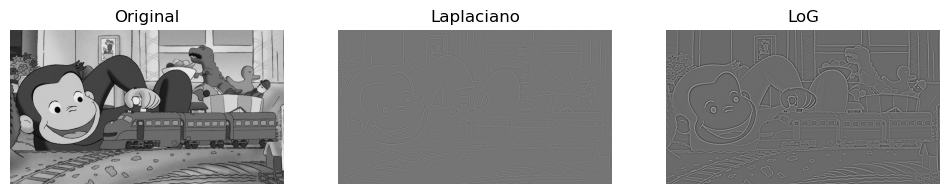

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
img = cv2.imread('imagen.jpg', 0)

# =========================
# LAPLACIANO
# =========================

laplaciano = cv2.Laplacian(img, cv2.CV_64F)

# =========================
# LAPLACIANO DEL GAUSSIANO
# =========================

# Suavizado Gaussiano
gauss = cv2.GaussianBlur(img, (5,5), 0)

# Aplicar Laplaciano
log = cv2.Laplacian(gauss, cv2.CV_64F)



plt.figure(figsize=(12,4))
# Imagen original
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

# Laplaciano
plt.subplot(1,3,2)
plt.imshow(laplaciano, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

# LoG
plt.subplot(1,3,3)
plt.imshow(log, cmap='gray')
plt.title('LoG')
plt.axis('off')

plt.show()

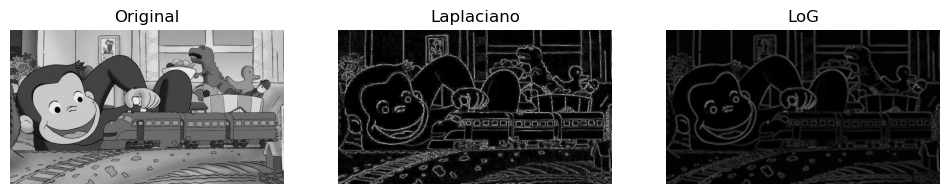

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen en gris
img = cv2.imread('imagen.jpg', 0)

# LAPLACIANO
laplaciano = cv2.Laplacian(img, cv2.CV_64F)
laplaciano_u8 = np.uint8(np.absolute(laplaciano))

# LAPLACIANO DEL GAUSSIANO
gauss = cv2.GaussianBlur(img, (5,5), 0)
log = cv2.Laplacian(gauss, cv2.CV_64F)
log_u8 = np.uint8(np.absolute(log))

# Guardar imágenes
cv2.imwrite('laplaciano.png', laplaciano_u8)
cv2.imwrite('log.png', log_u8)

# MOSTRAR RESULTADOS
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(laplaciano_u8, cmap='gray')
plt.title('Laplaciano')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_u8, cmap='gray')
plt.title('LoG')
plt.axis('off')

plt.show()